## $\text{IDR to USD Exchange Rate Prediction}$

Dataset Source - https://satudata.kemendag.go.id/data-informasi/perdagangan-dalam-negeri/nilai-tukar 

#### $\text{1. Import Dependencies}$

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

#### $\text{2. Load the Raw Dataset}$

In [ ]:
data = pd.read_csv("C:/Python Programming/idr2usd-exchange-rate/data/raw/idr2usd-exchange-rate.csv")
data

,Tahun,USD,JPY,DEM,NLG,GBP,FRH,CHF,SGD,MYR,HKD,AUD,CAD
0,2026,0,0,0,0,0,0,0,0,0,0,0,0
1,Mei,"17,789.00","11,174.00",0,0,"23,970.70",0,"22,677.05","13,924.31","4,485.40","2,270.21","12,743.16","12,885.92"
2,April,"17,324.00","10,850.00",0,0,"23,397.00",2,"21,953.00","13,565.00","4,385.00","2,211.00","12,409.00","12,663.00"
3,Maret,"16,993.00","10,635.00",0,0,"22,508.00",1,"21,245.00","13,182.00","4,216.00","2,169.00","11,642.00","12,217.00"
4,Februari,"16,758.00","10,739.00",0,0,"22,701.00",0,"21,713.00","13,270.00","4,311.00","2,142.00","11,937.00","12,267.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,2000,"9,595.00","8,357.00","4,557.00","4,044.00","14,299.00","1,359.00","5,860.00","5,539.00","2,525.00","5,319.00",460,"6,389.00"
332,1999,"7,100.00","6,947.00","3,655.00","3,243.00","11,495.00","1,090.00","4,450.00","4,260.00","1,868.00","4,622.00",369,"4,886.00"
333,1998,"8,025.00","7,000.00","4,777.00","4,240.00","13,336.00","1,424.00","5,807.00","4,836.00","2,112.00","4,923.00",482,"5,182.00"
334,1997,"4,650.00","3,578.00","2,598.00","2,306.00","7,709.00",776,"3,197.00","2,773.00","1,198.00","3,040.00",264,"3,247.00"


#### $\text{3. Creating the Desired Dataset}$

In [5]:
# List of the names of the months in Indonesian
bulan_list = [
    'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
    'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'
]

# Identify the row containing the year (4 digits)
mask_tahun = data['Tahun'].astype(str).str.fullmatch(r'\d{4}')

# Make the year column and forward fill 
data['tahun_tmp'] = np.where(mask_tahun, data['Tahun'], np.nan)
data['tahun_tmp'] = data['tahun_tmp'].ffill()

# Create a temporary year column and forward-fill it
df_usd = data[data['Tahun'].isin(bulan_list)].copy()

# Combine the month and year
df_usd['Bulan'] = (
    df_usd['Tahun'] + ' ' +
    df_usd['tahun_tmp'].astype(int).astype(str)
)

# Select only the Month and USD columns
df_usd = df_usd[['Bulan', 'USD']]

# Convert USD to float
df_usd['USD'] = (
    df_usd['USD']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Reset index to start from 0
df_usd = df_usd.reset_index(drop=True)

# Add a descending index column at the far left
df_usd.insert(0, 'Index', range(len(df_usd), 0, -1))

# Show results
df_usd

,Index,Bulan,USD
0,305,Mei 2026,17789.0
1,304,April 2026,17324.0
2,303,Maret 2026,16993.0
3,302,Februari 2026,16758.0
4,301,Januari 2026,16786.0
...,...,...,...
300,5,Mei 2001,11058.0
301,4,April 2001,11675.0
302,3,Maret 2001,10400.0
303,2,Februari 2001,9835.0


#### $\text{4. Save the Processed Data}$

In [21]:
df_usd.to_csv('C:/Python Programming/idr2usd-exchange-rate/data/processed/idr2usd-exchange-rate-processed.csv', index=False)

#### $\text{5. Exploratory Data Analysis}$

In [8]:
df_usd.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Index   305 non-null    int64  
 1   Bulan   305 non-null    str    
 2   USD     305 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 10.6 KB


In [7]:
df_usd.describe()

,Index,USD
count,305.000000,305.000000
mean,153.000000,11891.557377
std,88.190136,2713.415219
min,1.000000,8279.000000
25%,77.000000,9230.000000
50%,153.000000,11591.000000
75%,229.000000,14307.000000
max,305.000000,17789.000000


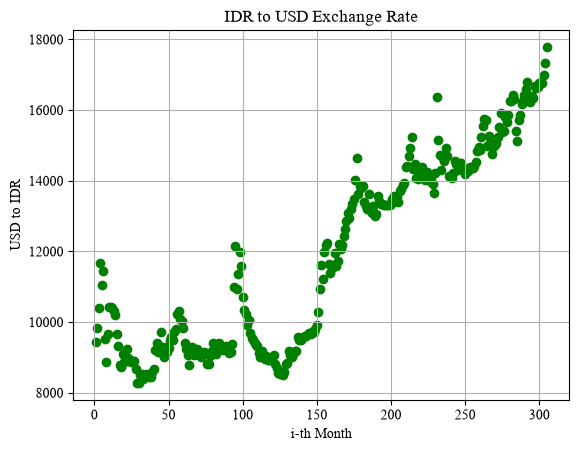

In [20]:
# Scatter Plot
plt.scatter(df_usd['Index'], df_usd['USD'], color='g')
plt.title('IDR to USD Exchange Rate')
plt.xlabel('i-th Month')
plt.ylabel('USD to IDR')
plt.grid()
plt.show()

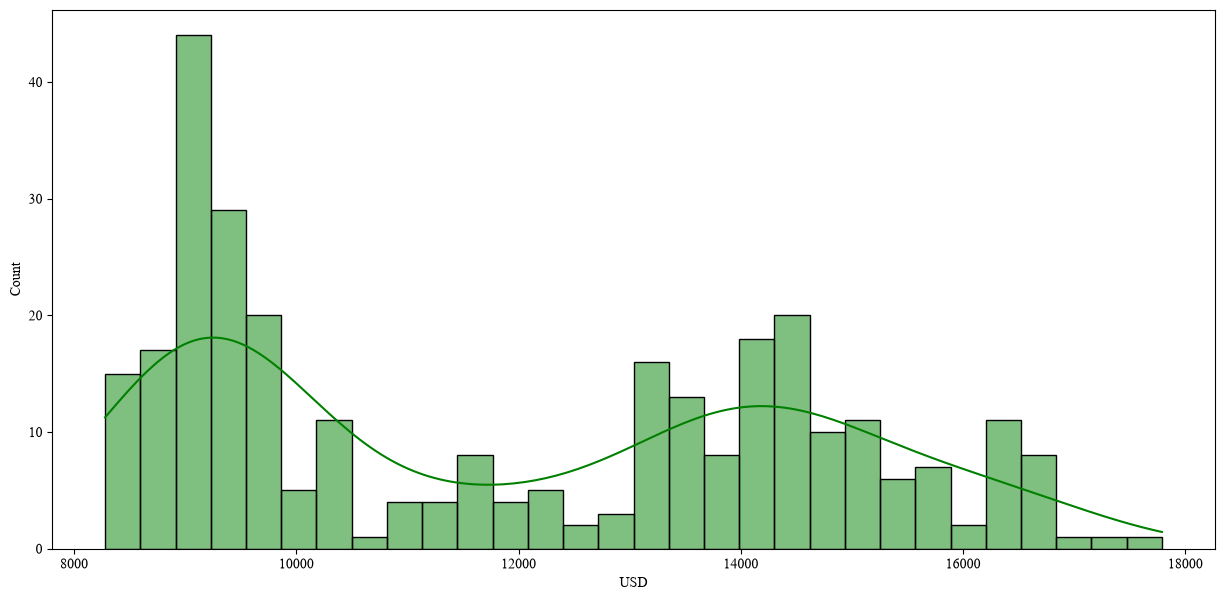

In [19]:
# Histogram with Density Line
fig, ax = plt.subplots(figsize=(15, 7))
sns.histplot(data=df_usd, x='USD', bins=30, kde=True, color='g')
plt.show()